In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

amazon = pd.read_csv('/AMAZON_daily.csv')
apple = pd.read_csv('/APPLE_daily.csv')
google = pd.read_csv('/GOOGLE_daily.csv')
meta = pd.read_csv('/META_daily.csv')
netflix = pd.read_csv('/NETFLIX_daily.csv')

amazon.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.097917
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.086458
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.085417
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.081771
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.071354


In [ ]:
amazon['Company'] = 'Amazon'
apple['Company'] = 'Apple'
google['Company'] = 'Google'
meta['Company'] = 'Meta'
netflix['Company'] = 'Netflix'


In [ ]:
amazon['Date'] = pd.to_datetime(amazon['Date'])
apple['Date'] = pd.to_datetime(apple['Date'])
google['Date'] = pd.to_datetime(google['Date'])
meta['Date'] = pd.to_datetime(meta['Date'])
netflix['Date'] = pd.to_datetime(netflix['Date'])


In [ ]:
maang_df = pd.concat([amazon, apple, google, meta, netflix], axis=0)
maang_df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Company
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.097917,Amazon
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.086458,Amazon
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.085417,Amazon
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.081771,Amazon
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.071354,Amazon


In [ ]:
# Dataset ka summary
maang_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33326 entries, 0 to 5945
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       33326 non-null  datetime64[ns]
 1   Open       33326 non-null  float64       
 2   High       33326 non-null  float64       
 3   Low        33326 non-null  float64       
 4   Close      33326 non-null  float64       
 5   Adj Close  33326 non-null  int64         
 6   Volume     33326 non-null  float64       
 7   Company    33326 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 2.3+ MB


In [ ]:
# Missing values check
maang_df.isnull().sum()


,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Company,0


In [ ]:
# Basic statistics
maang_df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,33326,33326.000000,33326.000000,33326.000000,33326.000000,3.332600e+04,33326.000000
mean,2010-09-09 13:05:32.929244672,54.656119,55.308785,53.997987,54.668172,1.815007e+08,54.668172
min,1980-12-12 00:00:00,0.037786,0.038072,0.034643,0.037286,0.000000e+00,0.037286
25%,2004-08-02 06:00:00,0.754463,0.777951,0.730414,0.753361,4.639492e+07,0.753361
50%,2012-10-05 00:00:00,12.746000,12.867084,12.594972,12.732670,1.015390e+08,12.732670
75%,2019-05-23 00:00:00,65.027750,65.999958,64.423833,65.272276,2.110836e+08,65.272276
max,2026-01-08 00:00:00,789.972167,795.064526,779.657506,788.823792,7.421641e+09,788.823792
std,NaN,96.637351,97.777775,95.438379,96.621953,2.468109e+08,96.621953


In [ ]:
maang_df = maang_df.dropna()

In [ ]:
maang_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Company'],
      dtype='object')

In [ ]:
maang_df['Daily_Return'] = maang_df['Adj Close'].pct_change()


In [ ]:
maang_df['MA_50'] = maang_df['Adj Close'].rolling(window=50).mean()
maang_df['MA_200'] = maang_df['Adj Close'].rolling(window=200).mean()


In [ ]:
maang_df['Price_Change'] = maang_df['High'] - maang_df['Low']


In [ ]:
maang_df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Company,Daily_Return,MA_50,MA_200,Price_Change
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.097917,Amazon,NaN,NaN,NaN,0.028646
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.086458,Amazon,-0.796275,NaN,NaN,0.013541
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.085417,Amazon,-0.584571,NaN,NaN,0.007292
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.081771,Amazon,-0.104736,NaN,NaN,0.005729
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.071354,Amazon,2.448420,NaN,NaN,0.013542


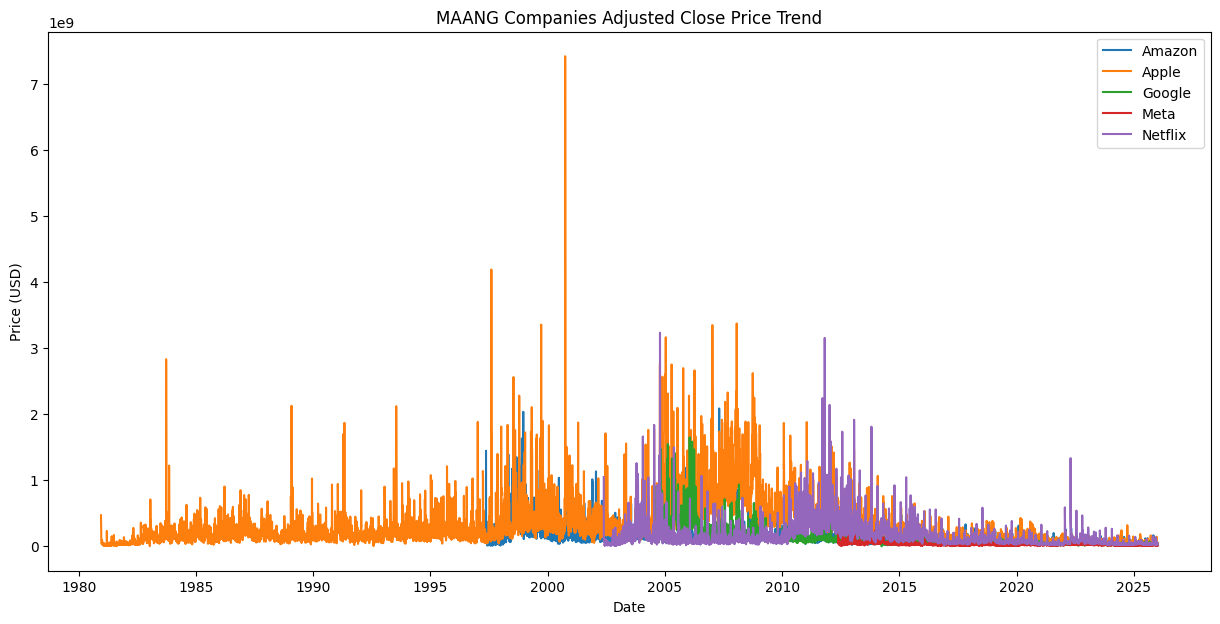

In [ ]:
# Close Price Trend (All Companies)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))
for company in maang_df['Company'].unique():
    temp = maang_df[maang_df['Company'] == company]
    plt.plot(temp['Date'], temp['Adj Close'], label=company)

plt.title('MAANG Companies Adjusted Close Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


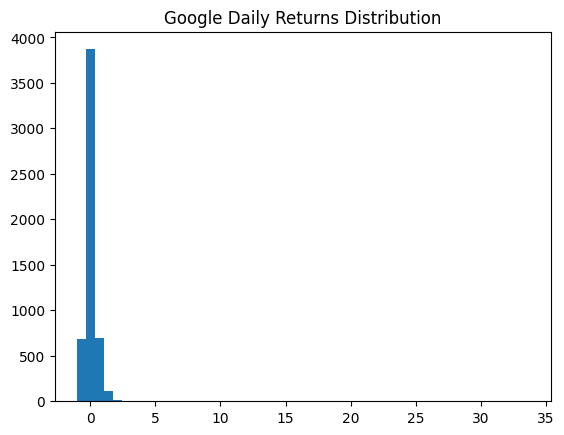

In [ ]:
# Daily Returns Histogram

google_df = maang_df[maang_df['Company'] == 'Google']
plt.hist(google_df['Daily_Return'].dropna(), bins=50)
plt.title('Google Daily Returns Distribution')
plt.show()


In [ ]:
# Correlation Matrix

pivot_df = maang_df.pivot(index='Date', columns='Company', values='Adj Close')
correlation = pivot_df.corr()
print(correlation)


Company    Amazon     Apple    Google      Meta   Netflix
Company                                                  
Amazon   1.000000  0.278174  0.370153  0.256122  0.122097
Apple    0.278174  1.000000  0.632932  0.478366  0.168555
Google   0.370153  0.632932  1.000000  0.480064  0.064242
Meta     0.256122  0.478366  0.480064  1.000000  0.360544
Netflix  0.122097  0.168555  0.064242  0.360544  1.000000


In [ ]:
# Top performing / least performing days → Trend insights

maang_df.sort_values('Daily_Return', ascending=False).head(5)


,Date,Open,High,Low,Close,Adj Close,Volume,Company,Daily_Return,MA_50,MA_200,Price_Change
166,1981-08-11,0.084701,0.084701,0.083845,0.083845,71456000,0.083845,Apple,inf,3.439072e+07,3.585095e+07,0.000856
526,1983-01-12,0.100956,0.107801,0.100956,0.105234,176982400,0.105234,Apple,126.435484,1.395117e+08,9.972256e+07,0.006845
0,2002-05-23,0.115643,0.124286,0.114571,0.119643,1047900000,0.119643,Netflix,87.009272,4.066905e+07,2.032723e+07,0.009715
2938,1992-07-28,0.326988,0.334175,0.325191,0.334175,134243200,0.334175,Apple,55.009346,1.835691e+08,1.685227e+08,0.008983
2422,2014-04-03,28.202960,29.065604,27.919866,28.197515,101983228,28.197515,Google,33.663943,8.373023e+07,7.798493e+07,1.145738


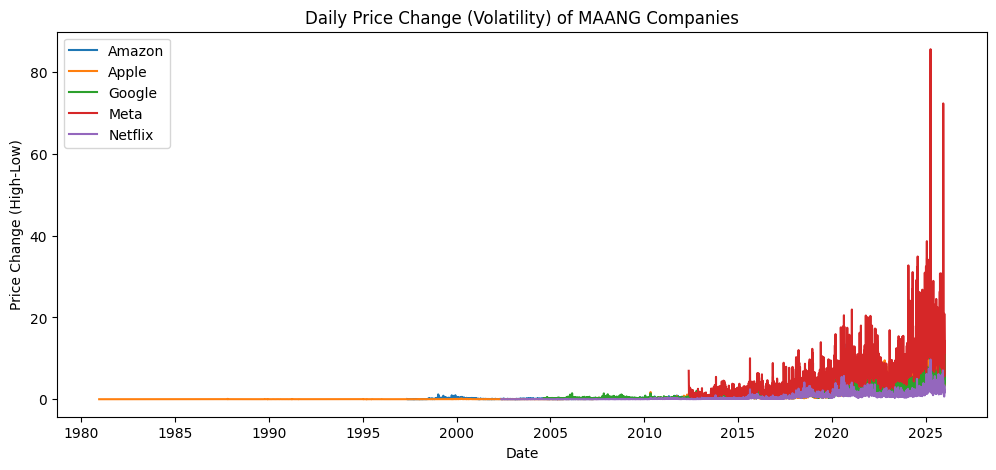

In [ ]:
# Volatility Analysis

plt.figure(figsize=(12,5))
for company in maang_df['Company'].unique():
    temp = maang_df[maang_df['Company']==company]
    plt.plot(temp['Date'], temp['Price_Change'], label=company)

plt.title('Daily Price Change (Volatility) of MAANG Companies')
plt.xlabel('Date')
plt.ylabel('Price Change (High-Low)')
plt.legend()
plt.show()


In [ ]:
# INSIGHTS

# Top 5 growth days per company
top_growth = maang_df.groupby('Company')['Daily_Return'].nlargest(5)
print(top_growth)


Company      
Amazon   1139     11.445787
         1915      5.950605
         2140      5.856982
         5691      5.814252
         1412      5.045857
Apple    166            inf
         526     126.435484
         2938     55.009346
         703      18.652471
         4209     15.956719
Google   2422     33.663943
         2421     17.569594
         0        16.818788
         5212      6.363499
         2058      4.426490
Meta     0        25.355697
         1422      7.087865
         296       3.422524
         130       3.195841
         2039      3.081623
Netflix  0        87.009272
         604      13.428656
         753       8.160262
         798       7.540523
         2346      7.142080
Name: Daily_Return, dtype: float64


In [ ]:
 # EVENT / SPECIAL DAY ANALYSIS

 # Filter 2020 COVID crash period
covid_df = maang_df[(maang_df['Date'] >= '2020-02-15') & (maang_df['Date'] <= '2020-04-15')]
covid_df.groupby('Company')['Adj Close'].min()


,Adj Close
Company,
Amazon,51224000
Apple,93984000
Google,18986000
Meta,12135100
Netflix,39301000


In [ ]:
# EXPORT CLEAN CSV

maang_df.to_csv('MAANG_Stock_Analysis.csv', index=False)
